In [ ]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

from Historical_price.EDA_raw_historical_price import clean_historical_price_dataset, load_tabular_data

PRICE_DATA_PATH = "historical_price_merged.parquet"


def load_price_data_for_eda(path: str | Path) -> pd.DataFrame:
    df = load_tabular_data(path)
    if "ticker" not in df.columns:
        out = clean_historical_price_dataset(df)["prepared_data"]
        out["ticker"] = out["symbol"].fillna("").astype(str).str.strip().str.upper()
    else:
        out = df.copy()
        out["symbol"] = out["symbol"].fillna("").astype(str).str.strip().str.upper()
        out["ticker"] = out["ticker"].fillna("").astype(str).str.strip().str.upper()

    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    return out


def build_missing_ratio(df: pd.DataFrame) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "column": df.columns,
            "number of missing rows": df.isna().sum().values,
            "missing pct": (df.isna().mean() * 100).round(2).values,
        }
    )


def build_duplicate_ticker_date_rows(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.loc[df.duplicated(subset=["ticker", "date"], keep=False)]
        .sort_values(["ticker", "date", "symbol"], kind="mergesort")
        .reset_index(drop=True)
    )


def build_symbol_date_panel(df: pd.DataFrame) -> pd.DataFrame:
    return df.sort_values(["symbol", "ticker", "date"], kind="mergesort").reset_index(drop=True)


def build_ticker_row_counts(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby("ticker", dropna=False)
        .size()
        .reset_index(name="row_count")
        .sort_values("ticker", kind="mergesort")
        .reset_index(drop=True)
    )


def build_universe_by_symbol(df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        df.groupby(["symbol", "ticker"], dropna=False)
        .agg(
            row_count=("symbol", "size"),
            min_date=("date", "min"),
            max_date=("date", "max"),
            zero_volume_days=("vol_total", lambda s: int(s.fillna(0).eq(0).sum())),
        )
        .reset_index()
        .sort_values(["row_count", "symbol"], ascending=[False, True], kind="mergesort")
    )
    return summary


def build_coverage_by_year(df: pd.DataFrame) -> pd.DataFrame:
    coverage = (
        df.groupby("year", dropna=False)
        .agg(
            row_count=("symbol", "size"),
            unique_symbols=("symbol", "nunique"),
            unique_tickers=("ticker", "nunique"),
            zero_volume_days=("vol_total", lambda s: int(s.fillna(0).eq(0).sum())),
        )
        .reset_index()
        .sort_values("year", kind="mergesort")
    )
    return coverage


def add_rolling_return_volatility(
    df: pd.DataFrame,
    window: int = 20,
    min_periods: int = 10,
) -> pd.DataFrame:
    out = df.copy()
    out["rolling_std_ret_20"] = (
        out.groupby("ticker", dropna=False)["ret_0"]
        .transform(lambda s: s.rolling(window, min_periods=min_periods).std())
    )
    return out


def add_lag_features(
    df: pd.DataFrame,
    lag_columns: list[str],
    max_lag: int = 5,
) -> pd.DataFrame:
    out = df.copy()
    ticker_group = out.groupby("ticker", dropna=False)

    for column in lag_columns:
        for lag in range(1, max_lag + 1):
            out[f"{column}_lag{lag}"] = ticker_group[column].shift(lag)
    return out


def build_feature(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out = out.sort_values(["ticker", "date"], kind="mergesort").reset_index(drop=True)
    ticker_group = out.groupby("ticker", dropna=False)

    previous_close = ticker_group["close_price"].shift(1)
    next_close_1 = ticker_group["close_price"].shift(-1)
    next_close_3 = ticker_group["close_price"].shift(-3)
    next_close_5 = ticker_group["close_price"].shift(-5)

    out["ret_0"] = np.log(out["close_price"] / previous_close)
    out["ret_1"] = np.log(next_close_1 / out["close_price"])
    out["ret_3"] = np.log(next_close_3 / out["close_price"])
    out["ret_5"] = np.log(next_close_5 / out["close_price"])

    out["log_vol_total"] = np.log1p(out["vol_total"].clip(lower=0))
    rolling_log_vol_mean = ticker_group["log_vol_total"].transform(
        lambda s: s.shift(1).rolling(20, min_periods=10).mean()
    )
    out["abn_vol"] = out["log_vol_total"] - rolling_log_vol_mean
    out["intraday_range_ratio"] = (out["high_price"] - out["low_price"]) / out["close_price"]
    out = add_rolling_return_volatility(out, window=20, min_periods=10)
    out = add_lag_features(
        out,
        lag_columns=["ret_0", "log_vol_total", "rolling_std_ret_20"],
        max_lag=5,
    )
    return out[
        [
            "ticker",
            "date",
            "close_price",
            "ret_0",
            "ret_1",
            "ret_3",
            "ret_5",
            "rolling_std_ret_20",
            "log_vol_total",
            "abn_vol",
            "intraday_range_ratio",
            "ret_0_lag1",
            "ret_0_lag2",
            "ret_0_lag3",
            "ret_0_lag4",
            "ret_0_lag5",
            "log_vol_total_lag1",
            "log_vol_total_lag2",
            "log_vol_total_lag3",
            "log_vol_total_lag4",
            "log_vol_total_lag5",
            "rolling_std_ret_20_lag1",
            "rolling_std_ret_20_lag2",
            "rolling_std_ret_20_lag3",
            "rolling_std_ret_20_lag4",
            "rolling_std_ret_20_lag5",
        ]
    ].copy()


def print_preview(title: str, df: pd.DataFrame, rows: int = 10) -> None:
    print(f"\n{title}:")
    if df.empty:
        print("Empty")
        return
    print(df.head(rows).to_string(index=False))


def main() -> None:
    raw_df = load_tabular_data(PRICE_DATA_PATH)
    raw_columns = list(raw_df.columns)
    df = load_price_data_for_eda(PRICE_DATA_PATH)

    missing_ratio = build_missing_ratio(df[raw_columns])
    duplicate_ticker_date_rows = build_duplicate_ticker_date_rows(df)
    symbol_date_panel = build_symbol_date_panel(df)
    ticker_row_counts = build_ticker_row_counts(df)
    universe_by_symbol = build_universe_by_symbol(df)
    coverage_by_year = build_coverage_by_year(df)
    feature = build_feature(df)

    print("Rows:", len(df))
    print("Unique symbols:", df["symbol"].nunique(dropna=True))
    print("Unique tickers:", df["ticker"].replace("", pd.NA).nunique(dropna=True))
    print("Date range:", df["date"].min(), "to", df["date"].max())
    print("Duplicate ticker-date rows:", len(duplicate_ticker_date_rows))

    print("Missing ratio (%)", missing_ratio)
    print_preview("Duplicate ticker-date rows", duplicate_ticker_date_rows)
    print_preview(
        "Symbol-date panel (sorted by symbol then date)",
        symbol_date_panel[
            [
                "symbol",
                "ticker",
                "date",
                "open_price",
                "high_price",
                "low_price",
                "close_price",
                "vol_total",
                "val_total",
            ]
        ],
    )
    print_preview("Row count by ticker", ticker_row_counts)
    # print_preview("Universe by symbol", universe_by_symbol)
    # print_preview("Coverage by year", coverage_by_year)
    # print_preview("Feature preview", feature)


if __name__ == "__main__":
    main()


Input rows: 1389555
Symbols required from symbols.csv: 1029
Tickers: 920
Duplicate ticker-date rows: 0
Rows with invalid OHLC: 542
Min date: 2010-01-04 00:00:00
Max date: 2019-12-31 00:00:00
Rows with year mismatch: 0
Rows with vol_total = 0: 407294
Rows with adj_ratio != 1: 1163050
Rows with vol_total != vol_deal + vol_putth: 3542
Rows with vol_total = 0 but OHLC changed: 288
Rows with all foreign flow fields missing: 0
Rows with all proprietary trading fields missing: 1388284


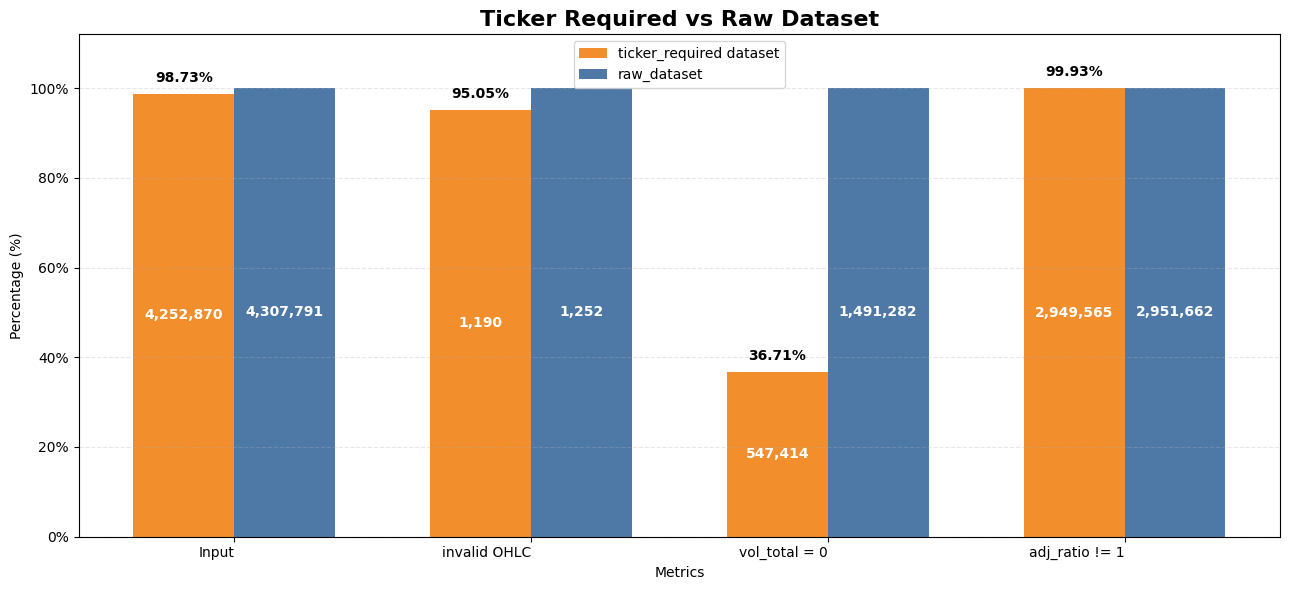

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

metrics = [
    "Input",
    "invalid OHLC",
    "vol_total = 0",
    "adj_ratio != 1",
]

raw_values = np.array([
    4_307_791,
    1_252,
    1_491_282,
    2_951_662,
], dtype=float)

ticker_required_values = np.array([
    4_252_870,
    1_190,
    547_414,
    2_949_565,
], dtype=float)

raw_pct = np.array([100, 100, 100, 100], dtype=float)
ticker_required_pct = ticker_required_values / raw_values * 100

x = np.arange(len(metrics))
width = 0.34

fig, ax = plt.subplots(figsize=(13, 6))

bars_ticker = ax.bar(
    x - width / 2,
    ticker_required_pct,
    width,
    color="#F28E2B",
    label="ticker_required dataset",
)

bars_raw = ax.bar(
    x + width / 2,
    raw_pct,
    width,
    color="#4E79A7",
    label="raw_dataset",
)

ax.set_title("Ticker Required vs Raw Dataset", fontsize=16, weight="bold")
ax.set_ylabel("Percentage (%)")
ax.set_xlabel("Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metrics, rotation=0, ha="right")
ax.set_ylim(0, 112)
ax.yaxis.set_major_formatter(PercentFormatter())
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.legend()

# Ghi số liệu thật bên trong cột cam
for bar, value in zip(bars_ticker, ticker_required_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{int(value):,}",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

# Ghi số liệu thật bên trong cột xanh
for bar, value in zip(bars_raw, raw_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        f"{int(value):,}",
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        fontweight="bold",
    )

# Ghi % phía trên cột cam
for bar, pct in zip(bars_ticker, ticker_required_pct):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{pct:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="black",
        fontweight="bold",
    )

plt.tight_layout()
plt.show()


In [8]:
from __future__ import annotations
from pathlib import Path
import pandas as pd


from EDA_ticker_required import (
        HISTORICAL_PRICE_PATH,
        REQUIRED_SYMBOLS_PATH,
        load_ticker_required_data,
)

OHLC_COLUMNS = ["open_price", "high_price", "low_price", "close_price"]


def drop_zero_ohlc_rows(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    zero_ohlc_mask = pd.Series(False, index=out.index)
    for column in OHLC_COLUMNS:
        zero_ohlc_mask |= out[column].notna() & out[column].eq(0)

    zero_ohlc_rows = out.loc[zero_ohlc_mask].copy()
    cleaned_df = out.loc[~zero_ohlc_mask].copy()
    return cleaned_df, zero_ohlc_rows


def normalize_zero_volume_ohlc_to_basic_price(
    df: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    complete_ohlc_mask = out[OHLC_COLUMNS].notna().all(axis=1)
    rounded_ohlc = out.loc[complete_ohlc_mask, OHLC_COLUMNS].round(3)
    zero_volume_ohlc_changed_mask = pd.Series(False, index=out.index)
    zero_volume_ohlc_changed_mask.loc[complete_ohlc_mask] = (
        out.loc[complete_ohlc_mask, "vol_total"].fillna(0).eq(0)
        & rounded_ohlc.max(axis=1).gt(rounded_ohlc.min(axis=1))
    )
    fix_mask = zero_volume_ohlc_changed_mask & out["basic_price"].notna()

    for column in OHLC_COLUMNS:
        out.loc[fix_mask, column] = out.loc[fix_mask, "basic_price"]

    normalized_rows = out.loc[fix_mask].copy()
    return out, normalized_rows


def build_clean_eda_data(
    path: str | Path = HISTORICAL_PRICE_PATH,
    required_symbols_path: str | Path = REQUIRED_SYMBOLS_PATH,
) -> dict[str, pd.DataFrame]:
    ticker_required_df = load_ticker_required_data(path, required_symbols_path)
    if "Ticker" in ticker_required_df.columns:
        ticker_required_df = ticker_required_df.rename(columns={"Ticker": "ticker"})
    without_zero_ohlc_df, zero_ohlc_rows = drop_zero_ohlc_rows(ticker_required_df)
    clean_df, normalized_zero_volume_ohlc_rows = normalize_zero_volume_ohlc_to_basic_price(
        without_zero_ohlc_df
    )

    sort_columns = ["ticker", "date"]
    clean_df = clean_df.sort_values(sort_columns, kind="mergesort").reset_index(drop=True)
    zero_ohlc_rows = zero_ohlc_rows.sort_values(sort_columns, kind="mergesort").reset_index(drop=True)
    normalized_zero_volume_ohlc_rows = normalized_zero_volume_ohlc_rows.sort_values(
        sort_columns,
        kind="mergesort",
    ).reset_index(drop=True)

    return {
        "ticker_required_data": ticker_required_df,
        "clean_eda_data": clean_df,
        "dropped_zero_ohlc_rows": zero_ohlc_rows,
        "normalized_zero_volume_ohlc_rows": normalized_zero_volume_ohlc_rows,
    }


def main() -> None:
    result = build_clean_eda_data()
    ticker_required_df = result["ticker_required_data"]
    clean_df = result["clean_eda_data"]
    dropped_zero_ohlc_rows = result["dropped_zero_ohlc_rows"]
    normalized_zero_volume_ohlc_rows = result["normalized_zero_volume_ohlc_rows"]

    print("Ticker-required input rows:", len(ticker_required_df))
    print("Rows dropped because OHLC = 0:", len(dropped_zero_ohlc_rows))
    print("Rows after OHLC cleaning:", len(clean_df))


if __name__ == "__main__":
    main()


Ticker-required input rows: 4252870
Rows dropped because OHLC = 0: 892
Rows after OHLC cleaning: 4251978


In [7]:
from __future__ import annotations
from pathlib import Path
import pandas as pd

from EDA_raw_historical_price import (
        HISTORICAL_PRICE_PATH,
        load_tabular_data,
        mark_duplicate_symbol_date,
        reconcile_year_from_date,
        remove_invalid_ohlc_rows,
        standardize_types,
)


def filter_vnindex_records(df: pd.DataFrame) -> pd.DataFrame:
    return df.loc[df["symbol"].eq("VNINDEX")].copy()


def collect_vnindex_issue_rows(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    out = df.copy()

    zero_vol_total_mask = out["vol_total"].notna() & out["vol_total"].eq(0)
    adj_ratio_not_one_mask = out["adj_ratio"].notna() & out["adj_ratio"].ne(1)
    adj_ratio_equal_one_mask = out["adj_ratio"].notna() & out["adj_ratio"].eq(1)

    ohlc_columns = ["open_price", "high_price", "low_price", "close_price"]
    complete_ohlc_mask = out[ohlc_columns].notna().all(axis=1)
    rounded_ohlc = out.loc[complete_ohlc_mask, ohlc_columns].round(3)
    zero_vol_total_but_ohlc_changed_mask = pd.Series(False, index=out.index)
    zero_vol_total_but_ohlc_changed_mask.loc[complete_ohlc_mask] = (
        out.loc[complete_ohlc_mask, "vol_total"].fillna(0).eq(0)
        & rounded_ohlc.max(axis=1).gt(rounded_ohlc.min(axis=1))
    )

    return {
        "zero_vol_total_rows": out.loc[zero_vol_total_mask].copy(),
        "adj_ratio_not_one_rows": out.loc[adj_ratio_not_one_mask].copy(),
        "adj_ratio_equal_one_rows": out.loc[adj_ratio_equal_one_mask].copy(),
        "zero_vol_total_but_ohlc_changed_rows": out.loc[
            zero_vol_total_but_ohlc_changed_mask
        ].copy(),
    }


def build_vnindex_eda(df: pd.DataFrame) -> dict[str, pd.DataFrame]:
    prepared_df = standardize_types(df)
    vnindex_df = filter_vnindex_records(prepared_df)
    vnindex_df, year_mismatch_rows = reconcile_year_from_date(vnindex_df)
    vnindex_df, duplicate_rows = mark_duplicate_symbol_date(vnindex_df)
    vnindex_df, invalid_ohlc_rows = remove_invalid_ohlc_rows(vnindex_df)
    issue_rows = collect_vnindex_issue_rows(vnindex_df)

    sort_columns = ["symbol", "date"]
    vnindex_df = vnindex_df.sort_values(sort_columns, kind="mergesort").reset_index(drop=True)
    year_mismatch_rows = year_mismatch_rows.sort_values(
        sort_columns,
        kind="mergesort",
    ).reset_index(drop=True)
    duplicate_rows = duplicate_rows.sort_values(
        sort_columns,
        kind="mergesort",
    ).reset_index(drop=True)
    invalid_ohlc_rows = invalid_ohlc_rows.sort_values(
        sort_columns,
        kind="mergesort",
    ).reset_index(drop=True)
    for key, issue_df in issue_rows.items():
        issue_rows[key] = issue_df.sort_values(
            sort_columns,
            kind="mergesort",
        ).reset_index(drop=True)

    return {
        "vnindex_data": vnindex_df,
        "year_mismatch_rows": year_mismatch_rows,
        "duplicate_rows": duplicate_rows,
        "invalid_ohlc_rows": invalid_ohlc_rows,
        **issue_rows,
    }


def load_vnindex_eda(path: str | Path = HISTORICAL_PRICE_PATH) -> dict[str, pd.DataFrame]:
    raw_df = load_tabular_data(path)
    return build_vnindex_eda(raw_df)


def main() -> None:
    result = load_vnindex_eda()
    vnindex_df = result["vnindex_data"]
    duplicate_rows = result["duplicate_rows"]
    year_mismatch_rows = result["year_mismatch_rows"]
    invalid_ohlc_rows = result["invalid_ohlc_rows"]
    zero_vol_total_but_ohlc_changed_rows = result["zero_vol_total_but_ohlc_changed_rows"]
    zero_vol_total_rows = result["zero_vol_total_rows"]
    adj_ratio_not_one_rows = result["adj_ratio_not_one_rows"]
    adj_ratio_equal_one_rows = result["adj_ratio_equal_one_rows"]
    parsed_dates = pd.to_datetime(vnindex_df["date"], errors="coerce")

    print("Input records:", len(vnindex_df))
    print("Min Date:", parsed_dates.min())
    print("Max Date:", parsed_dates.max())
    print("Duplicate records by symbol-date:", len(duplicate_rows))
    print("Rows with year mismatch:", len(year_mismatch_rows))
    print("Rows with invalid OHLC:", len(invalid_ohlc_rows))
    print("Rows with vol_total = 0 but OHLC changed:", len(zero_vol_total_but_ohlc_changed_rows))
    print("Rows with vol_total = 0:", len(zero_vol_total_rows))
    print("Rows with adj_ratio != 1:", len(adj_ratio_not_one_rows))
    print("Rows with adj_ratio = 1:", len(adj_ratio_equal_one_rows))

if __name__ == "__main__":
    main()


Input records: 3826
Min Date: 2010-01-04 00:00:00
Max Date: 2025-05-12 00:00:00
Duplicate records by symbol-date: 0
Rows with year mismatch: 0
Rows with invalid OHLC: 0
Rows with vol_total = 0 but OHLC changed: 0
Rows with vol_total = 0: 0
Rows with adj_ratio != 1: 0
Rows with adj_ratio = 1: 3826


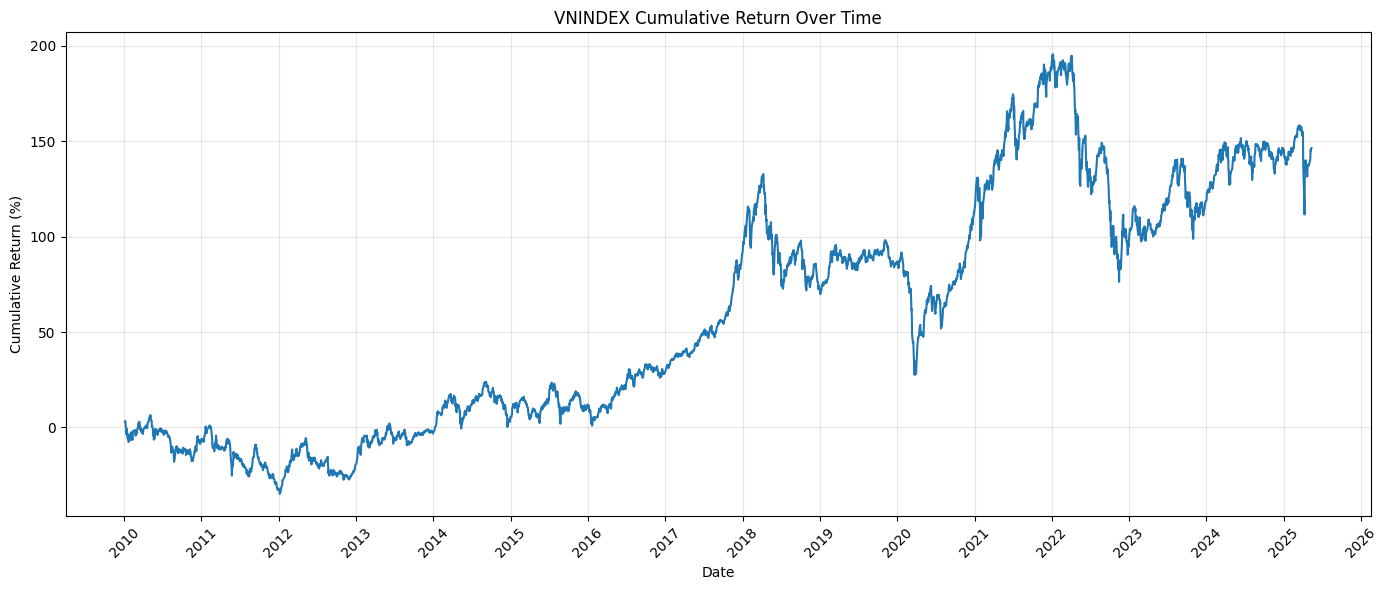

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

result = load_vnindex_eda()
vnindex_df = result["vnindex_data"]

plot_df = vnindex_df[["date", "close_price"]].copy()

plot_df["date"] = pd.to_datetime(plot_df["date"], errors="coerce")
plot_df["close_price"] = pd.to_numeric(plot_df["close_price"], errors="coerce")

plot_df = plot_df.dropna(subset=["date", "close_price"])
plot_df = plot_df.sort_values("date").reset_index(drop=True)

# Tính daily return
plot_df["daily_return"] = plot_df["close_price"].pct_change()

# Tính cumulative return
plot_df["cumulative_return"] = (1 + plot_df["daily_return"]).cumprod() - 1

# Đổi sang %
plot_df["cumulative_return_pct"] = plot_df["cumulative_return"] * 100

plt.figure(figsize=(14, 6))

plt.plot(
    plot_df["date"],
    plot_df["cumulative_return_pct"],
    linewidth=1.5
)

plt.title("VNINDEX Cumulative Return Over Time")
plt.xlabel("Date")
plt.ylabel("Cumulative Return (%)")
plt.grid(True, alpha=0.3)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# Lấy dữ liệu clean từ pipeline của bạn
result = build_clean_eda_data()
clean_df = result["clean_eda_data"].copy()

# Chuẩn hóa date và tạo year từ date
clean_df["date"] = pd.to_datetime(clean_df["date"], errors="coerce")
clean_df["year_from_date"] = clean_df["date"].dt.year.astype("Int64")

# Tạo cờ vol_total = 0 hoặc val_total = 0
zero_vol_or_val_mask = (
    clean_df["vol_total"].fillna(0).eq(0)
    | clean_df["val_total"].fillna(0).eq(0)
)

# Bảng summary theo năm
year_summary = (
    clean_df.assign(_zero_vol_or_val=zero_vol_or_val_mask)
    .loc[clean_df["year_from_date"].notna()]
    .groupby("year_from_date", dropna=False)
    .agg(
        **{
            "Unique Ticker": ("ticker", "nunique"),
            "Records": ("ticker", "size"),
            "Volumn/val_total = 0": ("_zero_vol_or_val", "sum"),
        }
    )
    .reset_index()
    .rename(columns={"year_from_date": "Year"})
    .sort_values("Year")
    .reset_index(drop=True)
)

# # Nếu muốn thêm sẵn 2020, 2021 dù không có dữ liệu
# full_years = pd.DataFrame({"Year": list(range(2010, 2022))})
# year_summary = (
#     full_years.merge(year_summary, on="Year", how="left")
#     .fillna("")
# )

year_summary.head(20)

,Year,Unique Ticker,Records,Volumn/val_total = 0
0,2010,632,131682,9773
1,2011,699,166397,32456
2,2012,721,176983,42430
3,2013,736,179437,51043
4,2014,760,180885,42349
5,2015,857,196491,55148
6,2016,990,226525,70229
7,2017,1245,281814,101084
8,2018,1371,327271,143514
9,2019,1430,350061,165886


In [ ]:
import pandas as pd
df = pd.read_parquet("../data_Histo/historical_price_all.parquet")
df.loc[df["symbol"].apply(lambda x: isinstance(x, str) and len(x) == 3), "symbol"].drop_duplicates().to_csv("unique_symbols.csv", index=False)